[*********************100%***********************]  1 of 1 completed


Expiration: 2026-06-12
T: 0.051587301587301584
S: 577.6997680664062
K: 580.0
bid: 176.23 ask: 179.05
call_price check: 10.077478123109245
vega check:       52.34435129138721
yfinance IV: 0.7045927978515626
market_price: 177.64
Valid strikes computed: 168
Test price: 10.077478123109245
Recovered IV: 0.2


c:\Users\andre\OneDrive\Documents\Visual Studio Code Projects\andrewnowak-options-pricing-engine\src\volatility.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  sigma = error - error / vega_value
c:\Users\andre\OneDrive\Documents\Visual Studio Code Projects\andrewnowak-options-pricing-engine\src\black_scholes.py:23: RuntimeWarning: invalid value encountered in scalar divide
  return numerator / denominator


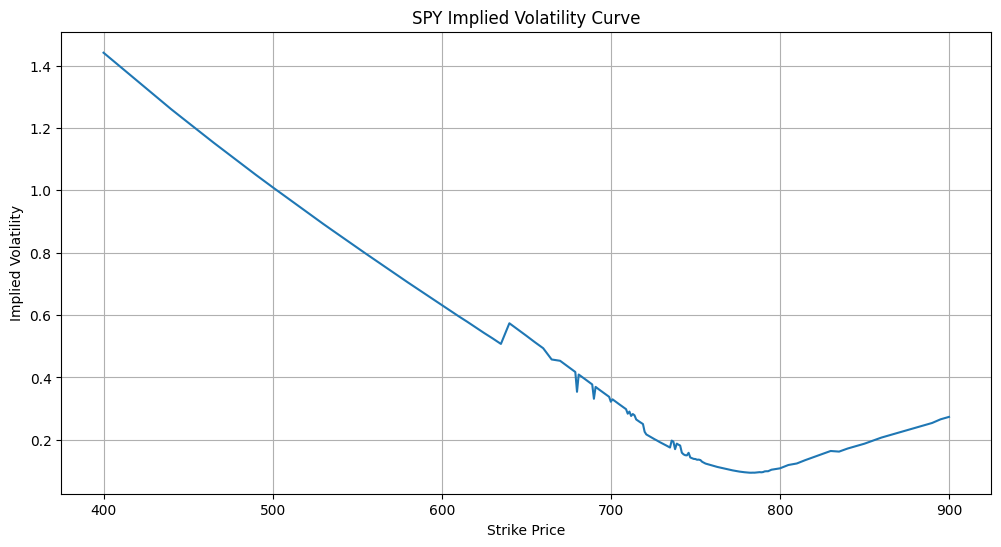

In [22]:
# -- Generate IV From Extracting SPY Data

# Import 
import sys
import os

sys.path.append(os.path.abspath(".."))

import yfinance as yf 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from src.volatility import implied_volatility_call, implied_volatility_put
from src.greeks import vega
from src.black_scholes import call_price

# Grab SPY Data
spy = yf.download(
    "SPY",
    start="2020-10-01",
    end="2025-01-01"
)

spy.tail()

ticker = yf.Ticker("SPY")

expiration = ticker.options[6]
chain = ticker.option_chain(expiration)

calls = chain.calls
puts = chain.puts

calls.head()

# Define Inputs 
S = float(spy["Close"].iloc[-1].item())
r = 0.05

today = datetime.today()
expiry = datetime.strptime(expiration, "%Y-%m-%d")

T = max((expiry - today).days / 252, 1e-6)

# Helper: Get Clean Market Price
def get_market_price(opt):
    bid = float(opt["bid"])
    ask = float(opt["ask"])
    last = float(opt["lastPrice"])

    mid = (bid + ask) / 2 if bid > 0 and ask > 0 and ask > bid else None
    price = mid if mid is not None else (last if last > 0 else None)

    # Sanity check: call price must be less than stock price
    if price is None or price >= S:
        return None

    return price

# Compute IV for a Single Option
atm_index = (calls["strike"] - S).abs().argmin()
sample = calls.iloc[atm_index]

K = float(sample["strike"])
bid = float(sample["bid"])
ask = float(sample["ask"])

# Debug Prints
print("Expiration:", expiration)
print("T:", T)
print("S:", S)
print("K:", K)
print("bid:", bid, "ask:", ask)
print("call_price check:", call_price(S, K, T, r, sigma=0.2))
print("vega check:      ", vega(S, K, T, r, sigma=0.2))
print("yfinance IV:", float(sample["impliedVolatility"]))

# Compute IV for a Single Option Continued
market_price = get_market_price(sample)
if market_price is None:
    raise ValueError("No valid market price available")

print("market_price:", market_price)

iv = implied_volatility_call(
    market_price,
    S,
    K,
    T,
    r=0.05
)

# Compute IV Across Multiple Strikes
strikes = []
ivs = []

for _, opt in calls.iterrows():
    try:
        K = float(opt["strike"])
        iv = float(opt["impliedVolatility"])

        if iv is None or np.isnan(iv) or iv <= 0:
            continue

        strikes.append(K)
        ivs.append(iv)

    except Exception as e:
        print(f"Skipped strike {opt.get('strike', None)} due to error: {e}")
        continue

# Clean Up Data
df = pd.DataFrame({
    "strike": strikes,
    "iv": ivs
})

df = df.dropna()
df = df.sort_values("strike")

print("Valid strikes computed:", len(df))

# Verify IV Works on Clean Data
test_price = call_price(S, 580, T, r, sigma=0.20)
print("Test price:", test_price)
print("Recovered IV:", implied_volatility_call(test_price, S, 580, T, r))
# Should print ~0.20

# Plot IV Curve 
plt.figure(figsize=(12,6))

plt.plot(df["strike"], df["iv"])

plt.title("SPY Implied Volatility Curve")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility")

plt.grid(True)
plt.show()